# Sprint 2 — Feature engineering

    Las features ya están centralizadas en `src/preprocessing.py` para no duplicar lógica entre notebooks.

as nuevas variables fueron diseñadas para capturar relaciones económicas entre el costo de adquisición y el valor estimado de mercado del vehículo.

Los ratios permiten identificar posibles sobreprecios, mientras que los márgenes representan potenciales ganancias o pérdidas de reventa.

Las variables temporales (PurchMonth, PurchQuarter, PurchDayOfWeek) buscan capturar posibles patrones estacionales en las compras de vehículos.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.io_utils import load_kick_data, save_df
from src.preprocessing import prepare_features, split_X_y

pd.set_option('display.max_columns', 120)
print('Proyecto:', PROJECT_ROOT)

Proyecto: c:\Users\PONCE\dp261-g1


In [2]:
df_raw = load_kick_data()
df_feat = prepare_features(df_raw)
new_cols = sorted(set(df_feat.columns) - set(df_raw.columns))
print('Features nuevas:', new_cols)
display(df_feat[new_cols + [TARGET]].head())

Features nuevas: ['PurchDayOfWeek', 'PurchMonth', 'PurchQuarter', 'PurchYear', 'acq_auction_margin', 'cost_to_acq_auction_avg', 'cost_to_current_auction_avg', 'current_auction_margin', 'current_vs_acq_auction_avg', 'warranty_to_cost']


,PurchDayOfWeek,PurchMonth,PurchQuarter,PurchYear,acq_auction_margin,cost_to_acq_auction_avg,cost_to_current_auction_avg,current_auction_margin,current_vs_acq_auction_avg,warranty_to_cost,IsBadBuy
0,0,12,4,2009,1055.0,0.870632,0.952892,351.0,-704.0,0.156761,0
1,0,12,4,2009,-746.0,1.108842,1.019313,-144.0,602.0,0.138553,0
2,0,12,4,2009,-1698.0,1.530294,1.214374,-865.0,833.0,0.283469,0
3,0,12,4,2009,-2207.0,2.165874,2.223427,-2256.0,-49.0,0.153659,0
4,0,12,4,2009,-87.0,1.022234,1.231906,-753.0,-666.0,0.255000,0


## Features creadas

- Componentes de fecha: capturan estacionalidad y cambios temporales.
- Ratios costo/MMR: miden si el precio pagado está alto o bajo contra mercado.
- Márgenes MMR - costo: aproximan colchón económico de reventa.
- Warranty/costo: aproxima riesgo relativo de garantía.

Si alguna feature tiene demasiados nulos, no se elimina automáticamente: se imputa dentro del pipeline usando solo train.

In [3]:
display(pd.DataFrame({
    'missing_pct': df_feat[new_cols].isna().mean().mul(100),
    'mean': df_feat[new_cols].mean(numeric_only=True)
}).sort_values('missing_pct', ascending=False))

,missing_pct,mean
current_vs_acq_auction_avg,1.625036,-25.197223
cost_to_acq_auction_avg,1.252346,1.168468
acq_auction_margin,1.252346,-531.826278
cost_to_current_auction_avg,1.213981,1.179857
current_auction_margin,1.213981,-557.784152
warranty_to_cost,0.093172,0.227572
PurchMonth,0.000000,6.608018
PurchDayOfWeek,0.000000,1.922324
PurchQuarter,0.000000,2.535769
PurchYear,0.000000,2009.519600


In [4]:
corr_target = (
    df_feat[new_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
)

display(corr_target)

IsBadBuy                       1.000000
cost_to_acq_auction_avg        0.100242
cost_to_current_auction_avg    0.076117
PurchDayOfWeek                 0.035388
PurchYear                      0.022301
warranty_to_cost               0.012369
current_vs_acq_auction_avg     0.003828
PurchMonth                    -0.007946
PurchQuarter                  -0.012577
current_auction_margin        -0.065441
acq_auction_margin            -0.071977
Name: IsBadBuy, dtype: float64

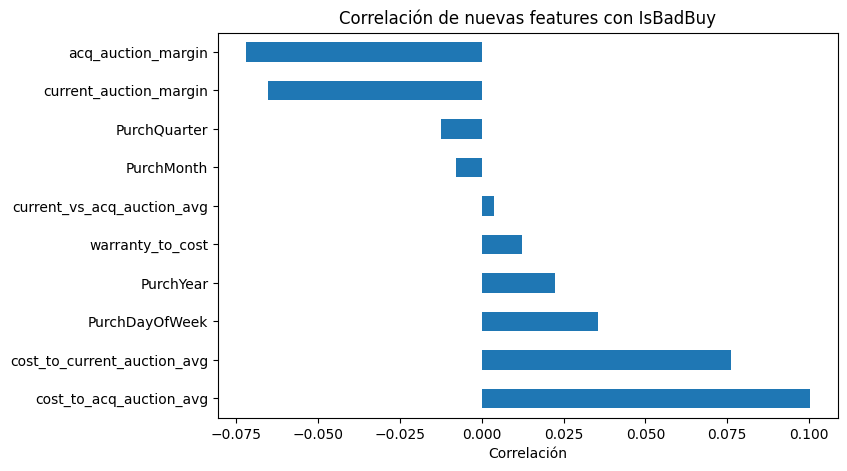

In [5]:
plt.figure(figsize=(8,5))
corr_target.drop(TARGET).plot(kind='barh')
plt.title('Correlación de nuevas features con IsBadBuy')
plt.xlabel('Correlación')
plt.show()

Las variables derivadas relacionadas con ratios de costo y márgenes de mercado presentan las mayores correlaciones con la variable objetivo.

En particular, cost_to_acq_auction_avg muestra una correlación positiva con IsBadBuy, sugiriendo que los vehículos comprados por encima del valor promedio de mercado presentan mayor riesgo de ser clasificados como compras problemáticas.

Por otro lado, los márgenes (acq_auction_margin y current_auction_margin) presentan correlaciones negativas, indicando que mayores márgenes económicos podrían asociarse con menor riesgo.

Aunque las correlaciones son moderadas, estas variables podrían aportar información útil para modelos no lineales basados en árboles.